# PixelCNN Prior Training for VQ-VAE

This notebook trains a prior over the discrete code
grid produced by a trained VQ-VAE.

Objectives:
1. Load a trained VQ-VAE checkpoint
2. Extract codebook indices for the full training set
3. Train a PixelCNN on those code grids
4. Sample new code grids → decode through VQ-VAE → images


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1 — Setup & Imports

In [ ]:
import sys, time, json
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path('/content/drive/MyDrive/Bayes_Project')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')
print(f'PyTorch:      {torch.__version__}')
print(f'CUDA:         {torch.cuda.is_available()}')


Project root: /content/drive/MyDrive/Bayes_Project
PyTorch:      2.10.0+cu128
CUDA:         True


In [ ]:
from data.dataloader import get_dataloaders, IMAGE_SIZE
from models.base import get_model, MODEL_REGISTRY
import models.vq_vae  # noqa: F401
from models.pixelcnn_prior import PixelCNNPrior
from train.train_utils import load_checkpoint

print('Available models:', list(MODEL_REGISTRY.keys()))


Available models: ['vae', 'conv_vae', 'vq_vae']


## 2 — Configuration

In [ ]:
# VQ-VAE checkpoint
VQVAE_CHECKPOINT = str(PROJECT_ROOT / 'models' / 'checkpoints' / 'vq_vae_cifar10_final_fornow_best.pt')

# VQ-VAE config
DATASET         = 'cifar10'
INPUT_CHANNELS  = 3
HIDDEN_DIMS     = [64, 128]       # must match VQ-VAE training
LATENT_DIM      = 64              # embedding dim, must match
NUM_EMBEDDINGS  = 1024             # codebook size K, must match
RECON_LOSS_TYPE = 'mse'
DATA_ROOT       = str(PROJECT_ROOT / 'data' / 'raw')

# PixelCNN prior config
PRIOR_HIDDEN_DIM  = 256           # channel width of conv layers
PRIOR_NUM_LAYERS  = 15             # number of residual blocks
PRIOR_KERNEL_SIZE = 5

# Training
PRIOR_EPOCHS     = 100
PRIOR_LR         = 1e-4
PRIOR_BATCH_SIZE = 128
NUM_WORKERS      = 2

# Sampling
TEMPERATURE      = 1.0            # 1.0 = normal, <1 = sharper, >1 = more diverse
TOP_K            = None           # None = sample from full distribution

# Paths
PRIOR_CKPT_DIR   = str(PROJECT_ROOT / 'models' / 'checkpoints')
LOG_DIR          = str(PROJECT_ROOT / 'logs')
OUTPUT_DIR       = str(PROJECT_ROOT / 'outputs')

SEED = 42
DEVICE = None


## 3 — Device & Seed

In [ ]:
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if DEVICE:
    device = torch.device(DEVICE)
elif torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device: {device}')


Device: cuda


## 4 — Load Trained VQ-VAE

The VQ-VAE must be fully trained and frozen. We only use its encoder
(to extract codes) and decoder (to render generated samples).

In [ ]:
# Rebuild VQ-VAE with the same config
vqvae = get_model(
    'vq_vae',
    input_channels=INPUT_CHANNELS,
    image_size=IMAGE_SIZE,
    hidden_dims=HIDDEN_DIMS,
    latent_dim=LATENT_DIM,
    num_embeddings=NUM_EMBEDDINGS,
    recon_loss_type=RECON_LOSS_TYPE,
).to(device)

# Load checkpoint
ckpt = load_checkpoint(VQVAE_CHECKPOINT, vqvae, device=device)
print(f'Loaded VQ-VAE from epoch {ckpt["epoch"]}')
print(f'Checkpoint metrics: {ckpt["metrics"]}')
vqvae.eval()
for p in vqvae.parameters():
    p.requires_grad = False

# Determine code grid size
GRID_SIZE = vqvae.encoder.spatial
print(f'Code grid: {GRID_SIZE}x{GRID_SIZE} = {GRID_SIZE**2} positions')
print(f'Codebook:  {NUM_EMBEDDINGS} entries x {LATENT_DIM} dims')


Loaded VQ-VAE from epoch 5
Checkpoint metrics: {'codebook_usage': 0.3891984375, 'commitment_loss': 0.29048465995788575, 'perplexity': 207.88511293945314, 'psnr': 21.81392484741211, 'recon_loss': 22.22621053161621, 'ssim': 0.7972416049003601, 'total_loss': 23.678633911132813, 'vq_loss': 1.161938639831543}
Code grid: 8x8 = 64 positions
Codebook:  1024 entries x 64 dims


## 5 — Extract Codebook Indices

Run the full training set through the VQ-VAE encoder and store
the discrete code grids. This is fast — no backprop needed.

In [ ]:
train_loader, test_loader, channels = get_dataloaders(
    dataset_name=DATASET,
    batch_size=256,  # large batch for fast extraction
    data_root=DATA_ROOT,
    num_workers=NUM_WORKERS,
)

@torch.no_grad()
def extract_codes(model, loader, device):
    """Run all images through encoder and collect codebook indices."""
    all_codes = []
    for batch, _ in loader:
        batch = batch.to(device)
        enc_out = model.encode(batch)
        all_codes.append(enc_out['encoding_indices'].cpu())
    return torch.cat(all_codes, dim=0)

print('Extracting training codes...')
train_codes = extract_codes(vqvae, train_loader, device)
print(f'  Shape: {train_codes.shape}  dtype: {train_codes.dtype}')
print(f'  Unique codes used: {train_codes.unique().numel()} / {NUM_EMBEDDINGS}')

print('Extracting test codes...')
test_codes = extract_codes(vqvae, test_loader, device)
print(f'  Shape: {test_codes.shape}')


Extracting training codes...
  Shape: torch.Size([49920, 8, 8])  dtype: torch.int64
  Unique codes used: 406 / 1024
Extracting test codes...
  Shape: torch.Size([10000, 8, 8])


### Code DataLoaders

In [ ]:
train_code_ds = TensorDataset(train_codes)
test_code_ds  = TensorDataset(test_codes)

train_code_loader = DataLoader(
    train_code_ds, batch_size=PRIOR_BATCH_SIZE,
    shuffle=True, drop_last=True,
)
test_code_loader = DataLoader(
    test_code_ds, batch_size=PRIOR_BATCH_SIZE,
    shuffle=False, drop_last=False,
)

print(f'Train batches: {len(train_code_loader)}')
print(f'Test batches:  {len(test_code_loader)}')


Train batches: 390
Test batches:  79


### Code Distribution

## 6 — Build PixelCNN Prior

In [ ]:
prior = PixelCNNPrior(
    num_embeddings=NUM_EMBEDDINGS,
    grid_size=GRID_SIZE,
    hidden_dim=PRIOR_HIDDEN_DIM,
    num_layers=PRIOR_NUM_LAYERS,
    embedding_dim=LATENT_DIM,
    kernel_size=PRIOR_KERNEL_SIZE,
).to(device)

total_params = sum(p.numel() for p in prior.parameters())
print(f'PixelCNN params: {total_params:,}')
print(f'Grid: {GRID_SIZE}x{GRID_SIZE}, Vocab: {NUM_EMBEDDINGS}, '
      f'Hidden: {PRIOR_HIDDEN_DIM}, Layers: {PRIOR_NUM_LAYERS}')


PixelCNN params: 27,357,952
Grid: 8x8, Vocab: 1024, Hidden: 256, Layers: 15


## 7 — Optimizer

In [ ]:
optimizer = torch.optim.Adam(prior.parameters(), lr=PRIOR_LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=PRIOR_EPOCHS
)
print(f'Optimizer: Adam (lr={PRIOR_LR})')
print(f'Scheduler: CosineAnnealing over {PRIOR_EPOCHS} epochs')


Optimizer: Adam (lr=0.0001)
Scheduler: CosineAnnealing over 100 epochs


## 8 — Training Loop

In [ ]:
train_losses = []
val_losses = []
best_val_loss = float('inf')
prior_ckpt_path = Path(PRIOR_CKPT_DIR) / f'pixelcnn_{DATASET}_K{NUM_EMBEDDINGS}.pt'

print(f'Starting PixelCNN training for {PRIOR_EPOCHS} epochs ...\n')
start_time = time.time()

for epoch in range(1, PRIOR_EPOCHS + 1):

    # Train
    prior.train()
    epoch_loss = 0.0
    num_batches = 0
    for (batch_codes,) in train_code_loader:
        batch_codes = batch_codes.to(device)

        loss = prior.loss(batch_codes)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    train_loss = epoch_loss / num_batches
    train_losses.append(train_loss)

    # Evaluate
    prior.eval()
    val_loss_sum = 0.0
    val_batches = 0
    with torch.no_grad():
        for (batch_codes,) in test_code_loader:
            batch_codes = batch_codes.to(device)
            loss = prior.loss(batch_codes)
            val_loss_sum += loss.item()
            val_batches += 1

    val_loss = val_loss_sum / val_batches
    val_losses.append(val_loss)

    scheduler.step()

    # Checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': prior.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, prior_ckpt_path)

    lr_now = optimizer.param_groups[0]['lr']
    print(
        f'  Epoch {epoch:3d}/{PRIOR_EPOCHS}  |  '
        f'train_nll={train_loss:.4f}  '
        f'val_nll={val_loss:.4f}  '
        f'lr={lr_now:.2e}'
    )

elapsed = time.time() - start_time
print(f'\nFinished in {elapsed:.1f}s')
print(f'Best val NLL: {best_val_loss:.4f}')

# Bits per code position (for interpretability)
bpc = best_val_loss / np.log(2)
print(f'Best val bits/position: {bpc:.2f}  '
      f'(uniform would be {np.log2(NUM_EMBEDDINGS):.2f})')


Starting PixelCNN training for 100 epochs ...

  Epoch   1/100  |  train_nll=4.7078  val_nll=4.3167  lr=1.00e-04
  Epoch   2/100  |  train_nll=3.8565  val_nll=3.9349  lr=9.99e-05
  Epoch   3/100  |  train_nll=3.5986  val_nll=3.7451  lr=9.98e-05
  Epoch   4/100  |  train_nll=3.4631  val_nll=3.6628  lr=9.96e-05
  Epoch   5/100  |  train_nll=3.3777  val_nll=3.5796  lr=9.94e-05
  Epoch   6/100  |  train_nll=3.3219  val_nll=3.5340  lr=9.91e-05
  Epoch   7/100  |  train_nll=3.2752  val_nll=3.4993  lr=9.88e-05
  Epoch   8/100  |  train_nll=3.2418  val_nll=3.4663  lr=9.84e-05
  Epoch   9/100  |  train_nll=3.2119  val_nll=3.4385  lr=9.80e-05
  Epoch  10/100  |  train_nll=3.1878  val_nll=3.4378  lr=9.76e-05
  Epoch  11/100  |  train_nll=3.1668  val_nll=3.4019  lr=9.70e-05
  Epoch  12/100  |  train_nll=3.1481  val_nll=3.3933  lr=9.65e-05
  Epoch  13/100  |  train_nll=3.1310  val_nll=3.3845  lr=9.59e-05
  Epoch  14/100  |  train_nll=3.1156  val_nll=3.3701  lr=9.52e-05
  Epoch  15/100  |  train_nll

## 9 — Loss Curves

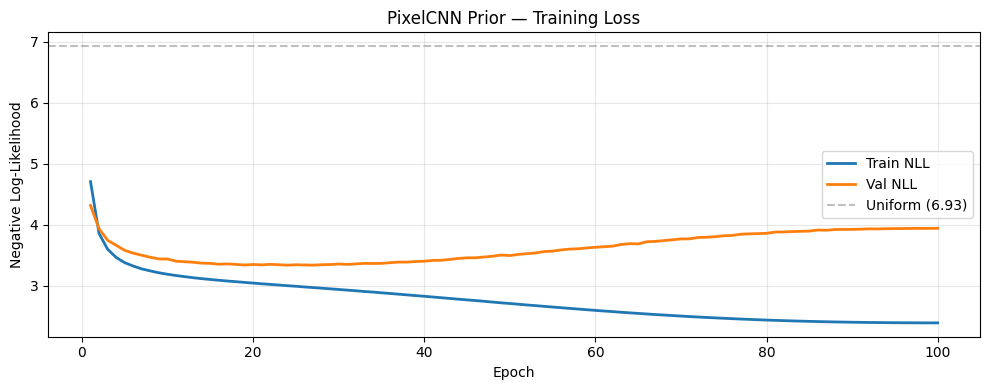

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, label='Train NLL', linewidth=2)
ax.plot(epochs_range, val_losses, label='Val NLL', linewidth=2)
ax.axhline(y=np.log(NUM_EMBEDDINGS), color='gray', linestyle='--',
           alpha=0.5, label=f'Uniform ({np.log(NUM_EMBEDDINGS):.2f})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Negative Log-Likelihood')
ax.set_title('PixelCNN Prior — Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10 — Generate Samples

Load the best checkpoint and sample code grids autoregressively,
then decode through the VQ-VAE.

In [ ]:
# Load best prior
best_ckpt = torch.load(prior_ckpt_path, map_location=device, weights_only=False)
prior.load_state_dict(best_ckpt['model_state_dict'])
prior.eval()
print(f'Loaded best prior from epoch {best_ckpt["epoch"]} '
      f'(val_nll={best_ckpt["val_loss"]:.4f})')


Loaded best prior from epoch 24 (val_nll=3.3369)


### Samples at Different Temperatures

Sampling at temperature=0.5 ...
Sampling at temperature=0.8 ...
Sampling at temperature=1.0 ...
Sampling at temperature=1.2 ...


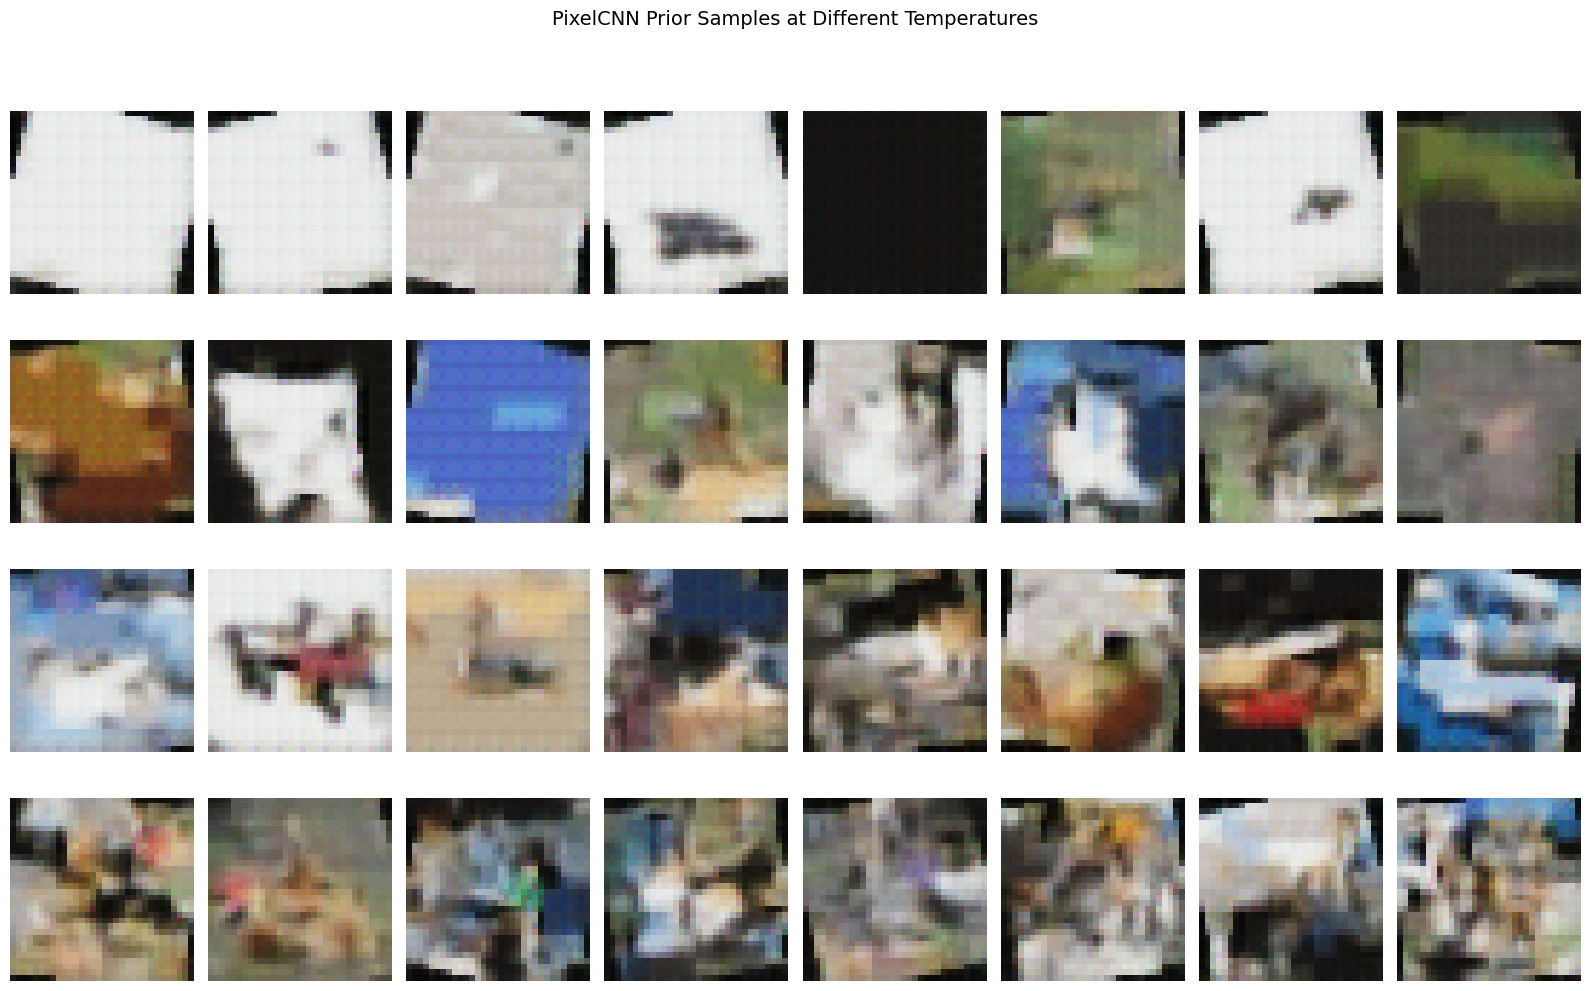

In [ ]:
temperatures = [0.5, 0.8, 1.0, 1.2]
num_per_temp = 8

fig, axes = plt.subplots(
    len(temperatures), num_per_temp,
    figsize=(2 * num_per_temp, 2.5 * len(temperatures))
)

for row, temp in enumerate(temperatures):
    print(f'Sampling at temperature={temp} ...')
    images = prior.decode_samples(
        vqvae, num_per_temp, device,
        temperature=temp,
    ).cpu().numpy()

    for col in range(num_per_temp):
        img = images[col]
        if img.shape[0] == 1:
            axes[row, col].imshow(img.squeeze(0), cmap='gray')
        else:
            axes[row, col].imshow(np.transpose(img, (1, 2, 0)))
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(f'T={temp}', fontsize=12,
                                       rotation=0, labelpad=40)

fig.suptitle('PixelCNN Prior Samples at Different Temperatures', fontsize=14, y=1.02)
fig.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / f'pixelcnn_{DATASET}_samples.png',
            dpi=150, bbox_inches='tight')
plt.show()


### Top-K Sampling

Sampling with top-50 ...
Sampling with top-100 ...
Sampling with full ...


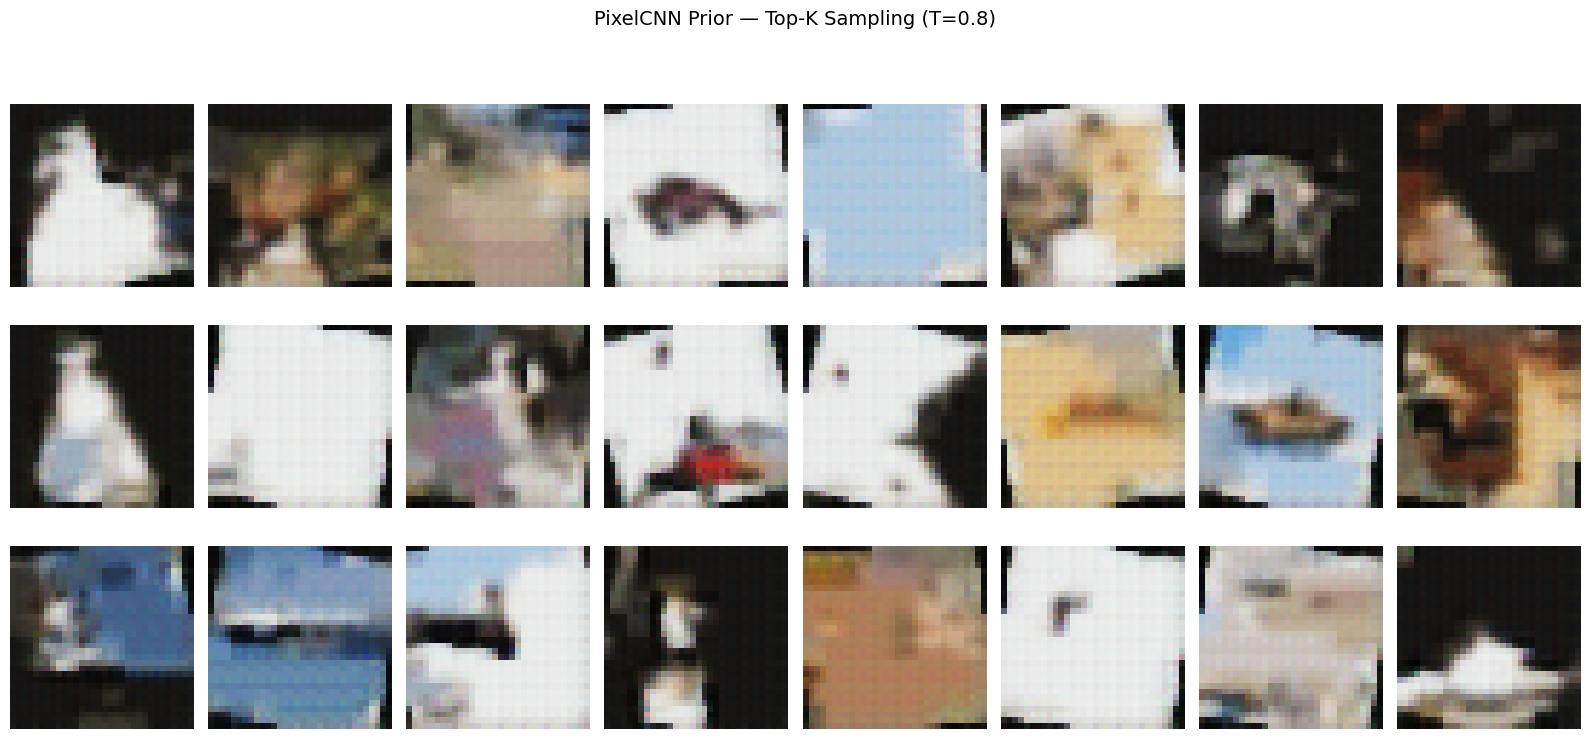

In [ ]:
top_k_values = [50, 100, None]  # None = no filtering
num_per_k = 8

fig, axes = plt.subplots(
    len(top_k_values), num_per_k,
    figsize=(2 * num_per_k, 2.5 * len(top_k_values))
)

for row, k in enumerate(top_k_values):
    label = f'top-{k}' if k else 'full'
    print(f'Sampling with {label} ...')
    images = prior.decode_samples(
        vqvae, num_per_k, device,
        temperature=0.8,
        top_k=k,
    ).cpu().numpy()

    for col in range(num_per_k):
        img = images[col]
        if img.shape[0] == 1:
            axes[row, col].imshow(img.squeeze(0), cmap='gray')
        else:
            axes[row, col].imshow(np.transpose(img, (1, 2, 0)))
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=12,
                                       rotation=0, labelpad=40)

fig.suptitle('PixelCNN Prior — Top-K Sampling (T=0.8)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


### Comparison: Random Codes vs Prior Samples vs Reconstructions

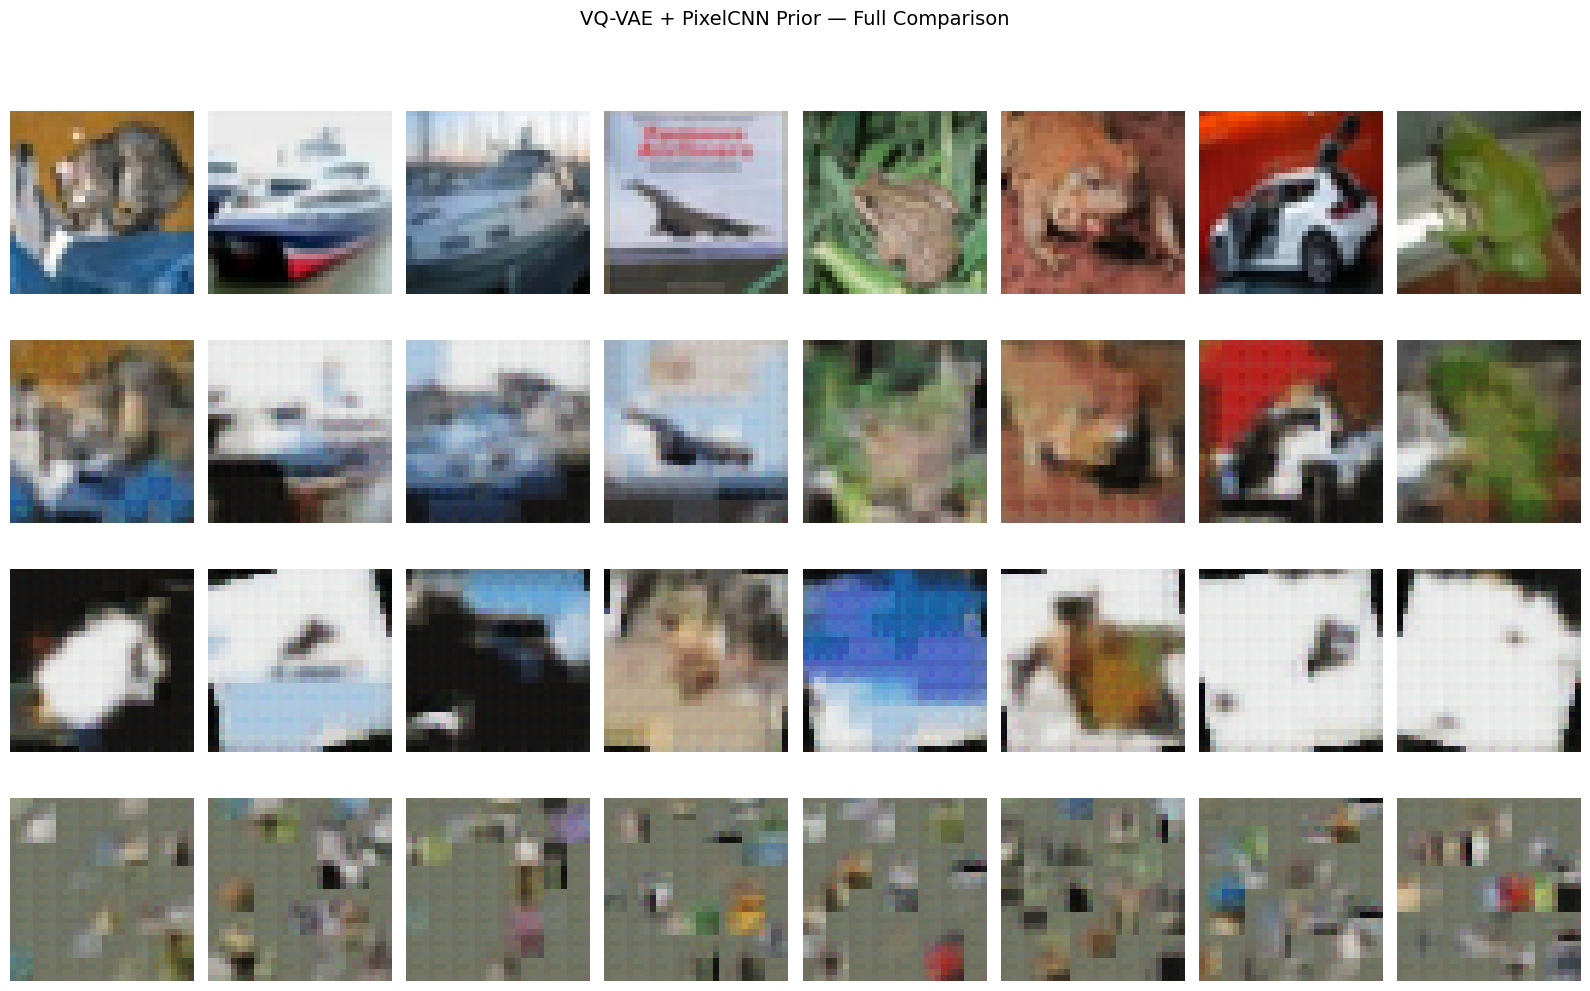

In [ ]:
num_compare = 8

test_batch, _ = next(iter(test_loader))
test_batch = test_batch[:num_compare].to(device)
with torch.no_grad():
    recon = vqvae.reconstruct(test_batch)

prior_images = prior.decode_samples(
    vqvae, num_compare, device, temperature=0.8
).cpu()

random_images = vqvae.sample(num_compare, device).cpu()

rows = [
    ('Original',      test_batch.cpu()),
    ('Reconstruction', recon.cpu()),
    ('Prior (T=0.8)', prior_images),
    ('Random codes',  random_images),
]

fig, axes = plt.subplots(len(rows), num_compare,
                         figsize=(2 * num_compare, 2.5 * len(rows)))

for r, (label, imgs) in enumerate(rows):
    for c in range(num_compare):
        img = imgs[c].clamp(0, 1).numpy()
        if img.shape[0] == 1:
            axes[r, c].imshow(img.squeeze(0), cmap='gray')
        else:
            axes[r, c].imshow(np.transpose(img, (1, 2, 0)))
        axes[r, c].axis('off')
        if c == 0:
            axes[r, c].set_ylabel(label, fontsize=11,
                                   rotation=0, labelpad=70)

fig.suptitle('VQ-VAE + PixelCNN Prior — Full Comparison', fontsize=14, y=1.02)
fig.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / f'vqvae_prior_comparison_{DATASET}.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 11 — Summary

In [ ]:
print('=' * 60)
print(f'  VQ-VAE checkpoint:  {VQVAE_CHECKPOINT}')
print(f'  Dataset:            {DATASET}')
print(f'  Code grid:          {GRID_SIZE}x{GRID_SIZE}')
print(f'  Codebook size:      {NUM_EMBEDDINGS}')
print(f'  Prior params:       {sum(p.numel() for p in prior.parameters()):,}')
print(f'  Prior layers:       {PRIOR_NUM_LAYERS}')
print(f'  Best val NLL:       {best_val_loss:.4f}')
print(f'  Bits/position:      {best_val_loss / np.log(2):.2f}')
print(f'  Training time:      {elapsed:.1f}s')
print(f'  Prior checkpoint:   {prior_ckpt_path}')
print('=' * 60)


  VQ-VAE checkpoint:  /content/drive/MyDrive/Bayes_Project/models/checkpoints/vq_vae_cifar10_final_fornow_best.pt
  Dataset:            cifar10
  Code grid:          8x8
  Codebook size:      1024
  Prior params:       27,357,952
  Prior layers:       15
  Best val NLL:       3.3369
  Bits/position:      4.81
  Training time:      16691.6s
  Prior checkpoint:   /content/drive/MyDrive/Bayes_Project/models/checkpoints/pixelcnn_cifar10_K1024.pt
